In [1]:
START_DATE = "2025-06-18"  # "2025-06-15"
END_DATE = "2025-07-15"

TRIALS_COUNT = 100
N_JOBS = 14
ZONES_DEFAULT_TO_SPAIN = True

In [2]:
RDC_PER_SIMULATIONS_COUNT = 10

PV_PROFILE_SCALING_FACTORS = [0, 2]
PV_PROFILE_CURVES_COUNT = RDC_PER_SIMULATIONS_COUNT

HYDRO_PROFILE_SCALING_FACTORS = [0, 2]
HYDRO_PROFILE_CURVES_COUNT = RDC_PER_SIMULATIONS_COUNT

BASIC_PROFILE_SCALING_FACTORS = [-1, 1]
BASIC_PROFILE_CURVES_COUNT = RDC_PER_SIMULATIONS_COUNT

In [3]:
PV_PROFILE = {
    1: 37.59996234939759,
    2: 37.16607680722892,
    3: 37.18817771084338,
    4: 37.12051957831326,
    5: 37.28509036144578,
    6: 38.26517319277109,
    7: 83.34126506024096,
    8: 647.6649472891567,
    9: 3538.156061746988,
    10: 8740.376167168675,
    11: 12744.203426204818,
    12: 14468.161671686743,
    13: 15119.776091867468,
    14: 15260.259751506024,
    15: 15039.367356927709,
    16: 14415.311219879515,
    17: 13096.334864457833,
    18: 10903.169239457831,
    19: 8124.012123493975,
    20: 4842.958509036145,
    21: 1618.0733810240965,
    22: 191.73309487951806,
    23: 41.091076807228916,
    24: 40.31780873493976,
}
HYDRO_PROFILE = {
    1: 4692.875037650602,
    2: 4242.930346385542,
    3: 3873.455986445783,
    4: 3717.952070783132,
    5: 3702.293185240964,
    6: 3849.4995858433736,
    7: 4492.3163780120485,
    8: 5157.214721385542,
    9: 5008.611069277108,
    10: 4078.6329819277107,
    11: 3236.83140060241,
    12: 2824.535768072289,
    13: 2674.7771837349396,
    14: 2623.8321159638554,
    15: 2594.9606927710843,
    16: 2618.682981927711,
    17: 2787.694465361446,
    18: 3331.8057228915663,
    19: 4140.421121987952,
    20: 5120.546536144579,
    21: 6142.721987951806,
    22: 6487.007756024097,
    23: 6077.225,
    24: 5345.29265813253,
}
BASIC_PROFILE = {i: 1500 for i in range(1, 25)}

In [4]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
FILE_DIR = os.getcwd()
# parent directory and src directory
SRC_DIR = os.path.join(os.path.dirname(FILE_DIR), "src")
DATA_DIR = os.path.join(os.path.dirname(FILE_DIR), "data")
print(f"Adding src directory to sys.path: {SRC_DIR}")
# Add the src directory to sys.path
sys.path.append(SRC_DIR)

Adding src directory to sys.path: /home/einsunza/Desktop/work/mibel-simulator/src


In [6]:
from mibel_simulator.residual_demand_curve import create_homothetic_sell_profiles
from mibel_simulator.residual_demand_curve import calculate_residual_demand_curves
import mibel_simulator.columns as cols

In [7]:
DET_FILEPATH_PATTERN = os.path.join(DATA_DIR, "DET/DET_{YYYYMMDD}.1")
CAB_FILEPATH_PATTERN = os.path.join(DATA_DIR, "CAB/CAB_{YYYYMMDD}.1")
CAPACIDAD_INTER_PBC_FILEPATH_PATTERN = os.path.join(
    DATA_DIR, "capacidad_inter_pbc/capacidad_inter_pbc_{YYYYMMDD}.1"
)
PRICE_FRANCE_FILEPATH = os.path.join(DATA_DIR, "price_france.parquet")

In [8]:
price_france_df = pd.read_parquet(PRICE_FRANCE_FILEPATH)

In [9]:
pv_profile = pd.Series(PV_PROFILE)
hydro_profile = pd.Series(HYDRO_PROFILE)
basic_profile = pd.Series(BASIC_PROFILE)

pv_scaling_factors = np.linspace(
    PV_PROFILE_SCALING_FACTORS[0],
    PV_PROFILE_SCALING_FACTORS[1],
    PV_PROFILE_CURVES_COUNT,
)
pv_sell_profiles = create_homothetic_sell_profiles(
    pv_profile,
    pv_scaling_factors,
)
hydro_scaling_factors = np.linspace(
    HYDRO_PROFILE_SCALING_FACTORS[0],
    HYDRO_PROFILE_SCALING_FACTORS[1],
    HYDRO_PROFILE_CURVES_COUNT,
)
hydro_sell_profiles = create_homothetic_sell_profiles(
    hydro_profile,
    hydro_scaling_factors,
)
basic_scaling_factors = np.linspace(
    BASIC_PROFILE_SCALING_FACTORS[0],
    BASIC_PROFILE_SCALING_FACTORS[1],
    BASIC_PROFILE_CURVES_COUNT,
)
basic_sell_profiles = create_homothetic_sell_profiles(
    basic_profile,
    basic_scaling_factors,
)

profiles_dict = {
    "pv": pv_sell_profiles,
    "hydro": hydro_sell_profiles,
    "basic": basic_sell_profiles,
}

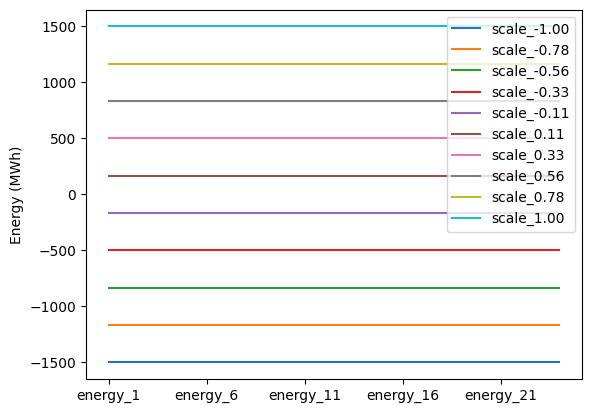

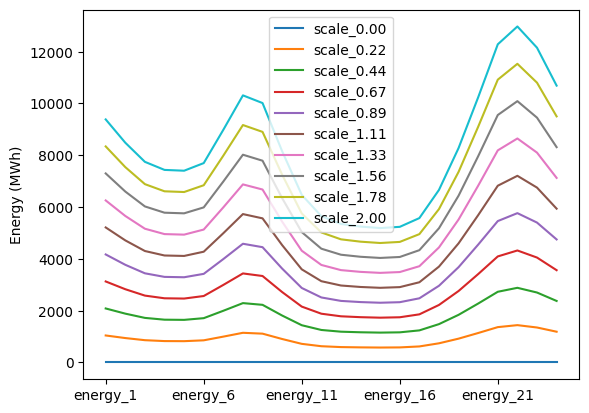

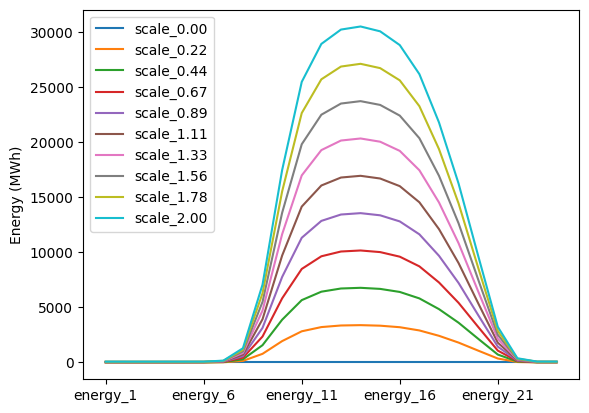

In [10]:
basic_sell_profiles.T.plot()
plt.ylabel("Energy (MWh)")
plt.show()
hydro_sell_profiles.T.plot()
plt.ylabel("Energy (MWh)")
plt.show()
pv_sell_profiles.T.plot()
plt.ylabel("Energy (MWh)")
plt.show()

In [ ]:
for date in pd.date_range(start=START_DATE, end=END_DATE):
    # profiles_dict
    for profile_name, sell_profiles in profiles_dict.items():
        try:
            date_studied = date.strftime("%Y-%m-%d")

            print(f"Processing date: {date.strftime('%Y-%m-%d')}")
            det_date = DET_FILEPATH_PATTERN.format(YYYYMMDD=date.strftime("%Y%m%d"))
            cab_date = CAB_FILEPATH_PATTERN.format(YYYYMMDD=date.strftime("%Y%m%d"))
            capacidad_inter_date = CAPACIDAD_INTER_PBC_FILEPATH_PATTERN.format(
                YYYYMMDD=date.strftime("%Y%m%d")
            )
            price_france_date = price_france_df[
                price_france_df[cols.DATE_SESION] == date
            ]

            start_time = time.time()
            residual_demand_curve = calculate_residual_demand_curves(
                sell_profiles,
                det_date,
                cab_date,
                capacidad_inter_date,
                price_france_date,
                sell_country="ES",
                trials_count=TRIALS_COUNT,
                zones_default_to_spain=ZONES_DEFAULT_TO_SPAIN,
                n_jobs=N_JOBS,
            )
            end_time = time.time()
            run_time = end_time - start_time

            residual_demand_curve.attrs["date_studied"] = date_studied
            residual_demand_curve.attrs["trials_count"] = TRIALS_COUNT
            residual_demand_curve.attrs["profile_name"] = profile_name
            residual_demand_curve.attrs["n_jobs"] = N_JOBS
            residual_demand_curve.attrs["sell_country"] = "ES"
            residual_demand_curve.attrs["run_time"] = str(run_time)

            residual_demand_curve.to_parquet(
                f"results/residual_demand_curve_{profile_name}_{date_studied}.parquet"
            )
        except Exception as e:
            print(
                f"Error processing date {date_studied} with profile {profile_name}: {e}"
            )
            continue

Processing date: 2025-06-18


Period 25 size is less than 0.1 times the size of the other periods, dropping it. You can ignore this, this is a typical issue with OMIE det files. File: /home/einsunza/Desktop/work/mibel-simulator/data/DET/DET_20250618.1


21 2775.7083333333335


The generated residual demand DET dataframe is empty. Check the input residual demand curve.
Profile scale_0.00 has empty residual demand, the results are similar to a normal clearing of the market.
/home/einsunza/Desktop/work/mibel-simulator/src/mibel_simulator/clearing_process.py:730: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  trials_df = pd.concat([trials_df] + results, ignore_index=True)
/home/einsunza/Desktop/work/mibel-simulator/src/mibel_simulator/clearing_process.py:730: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entrie

Processing date: 2025-06-18
21 2775.7083333333335


...

The generated residual demand DET dataframe is empty. Check the input residual demand curve.
Profile scale_0.00 has empty residual demand, the results are similar to a normal clearing of the market.
/home/einsunza/Desktop/work/mibel-simulator/src/mibel_simulator/clearing_process.py:730: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  trials_df = pd.concat([trials_df] + results, ignore_index=True)
/home/einsunza/Desktop/work/mibel-simulator/src/mibel_simulator/clearing_process.py:730: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entrie

Processing date: 2025-06-30


Period 25 size is less than 0.1 times the size of the other periods, dropping it. You can ignore this, this is a typical issue with OMIE det files. File: /home/einsunza/Desktop/work/mibel-simulator/data/DET/DET_20250630.1


20 2826.9583333333335


/home/einsunza/Desktop/work/mibel-simulator/src/mibel_simulator/clearing_process.py:730: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  trials_df = pd.concat([trials_df] + results, ignore_index=True)
/home/einsunza/Desktop/work/mibel-simulator/src/mibel_simulator/clearing_process.py:730: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  trials_df = pd.concat([trials_df] + results, ignore_index=True)
/home/einsunza/Desktop/work/mibel-simulator/src/mibel_simulator/clearing_process.py:730: FutureWarning